# A4: Phantom Image Denoising — Observation Summary

**Task:** Denoise 64×64 synthetic phantom images corrupted with Gaussian noise (factor=0.1).  
**Data:** 1000 phantom images → 900 train / 100 validation.  
**Training:** Adam optimizer, MSE loss, 100 epochs (all models use identical data).

---

## Architecture Summary

| Model    | Layers | Channels (encoder→bottleneck→decoder→output) | Total Params | Val MSE |
|----------|--------|----------------------------------------------|-------------|---------|
| Baseline | 13     | 1→15→15→20→20→25→25→25→25→20→20→15→15→1      | 43,036      | *see training output* |
| Case 1   | 14     | 1→32→32→64→64→128→128→256→128→128→64→64→32→32→1 | 1,162,945  | *see training output* |
| Case 2   | 3      | 1→2→2→1                                       | 77          | *see training output* |

---

## Observations

### Baseline (Lecture Model 2)
The baseline is the encoder-decoder Sequential model from the lecture with 43,036 parameters.
It uses strided Conv2D to downsample (encoder) and Conv2DTranspose to upsample (decoder),
with channel depths 15/20/25. All spatial information must pass through the 8×8×25 bottleneck.

### Case 1: Improved — Wider & Deeper Sequential (1,162,945 params)
**Change:** Much wider channels (32/64/128/256 vs 15/20/25) plus a dedicated bottleneck layer.  
**Why it improves:** ~27× more parameters gives the network dramatically more representational 
capacity at each spatial scale. Richer feature maps mean the decoder can reconstruct finer 
details. The sigmoid output activation also correctly bounds predictions to [0,1], matching 
the normalized clean image range (vs. relu which can exceed 0.5).  
**Expected result:** Lower validation MSE than baseline.

### Case 2: Worsened — Underpowered Shallow CNN (77 params)
**Change:** Only 3 layers with 2 channels each, no encoder-decoder structure.  
**Why it worsens:** 77 parameters is fundamentally insufficient to represent any meaningful 
denoising function. With no strided convolutions, the network has no multi-scale reasoning.
With only 2 filters, there is almost no feature diversity. The network is severely underfit 
and converges to near-trivially predicting close to the mean.  
**Expected result:** Higher validation MSE than baseline.


## Phantom Generator

In [27]:
## Copyright (C) 2010  Alex Opie  <lx_op@orcon.net.nz>
##
## This program is free software; you can redistribute it and/or modify it
## under the terms of the GNU General Public License as published by
## the Free Software Foundation; either version 3 of the License, or (at
## your option) any later version.
##
## This program is distributed in the hope that it will be useful, but
## WITHOUT ANY WARRANTY; without even the implied warranty of
## MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.	See the GNU
## General Public License for more details.
##
## You should have received a copy of the GNU General Public License
## along with this program; see the file COPYING.  If not, see
## <http://www.gnu.org/licenses/>.

import numpy as np

def phantom (n = 256, p_type = 'Modified Shepp-Logan', ellipses = None):
	"""
	 phantom (n = 256, p_type = 'Modified Shepp-Logan', ellipses = None)
	
	Create a Shepp-Logan or modified Shepp-Logan phantom.

	A phantom is a known object (either real or purely mathematical) 
	that is used for testing image reconstruction algorithms.  The 
	Shepp-Logan phantom is a popular mathematical model of a cranial
	slice, made up of a set of ellipses.  This allows rigorous 
	testing of computed tomography (CT) algorithms as it can be 
	analytically transformed with the radon transform (see the 
	function `radon').
	
	Inputs
	------
	n : The edge length of the square image to be produced.
	
	p_type : The type of phantom to produce. Either 
	  "Modified Shepp-Logan" or "Shepp-Logan".  This is overridden
	  if `ellipses' is also specified.
	
	ellipses : Custom set of ellipses to use.  These should be in 
	  the form
	  	[[I, a, b, x0, y0, phi],
	  	 [I, a, b, x0, y0, phi],
	  	 ...]
	  where each row defines an ellipse.
	  I : Additive intensity of the ellipse.
	  a : Length of the major axis.
	  b : Length of the minor axis.
	  x0 : Horizontal offset of the centre of the ellipse.
	  y0 : Vertical offset of the centre of the ellipse.
	  phi : Counterclockwise rotation of the ellipse in degrees,
	        measured as the angle between the horizontal axis and 
	        the ellipse major axis.
	  The image bounding box in the algorithm is [-1, -1], [1, 1], 
	  so the values of a, b, x0, y0 should all be specified with
	  respect to this box.
	
	Output
	------
	P : A phantom image.
	
	Usage example
	-------------
	  import matplotlib.pyplot as pl
	  P = phantom ()
	  pl.imshow (P)
	
	References
	----------
	Shepp, L. A.; Logan, B. F.; Reconstructing Interior Head Tissue 
	from X-Ray Transmissions, IEEE Transactions on Nuclear Science,
	Feb. 1974, p. 232.
	
	Toft, P.; "The Radon Transform - Theory and Implementation", 
	Ph.D. thesis, Department of Mathematical Modelling, Technical 
	University of Denmark, June 1996.
	
	"""
	
	if (ellipses is None):
		ellipses = _select_phantom (p_type)
	elif (np.size (ellipses, 1) != 6):
		raise AssertionError ("Wrong number of columns in user phantom")
	
	# Blank image
	p = np.zeros ((n, n))

	# Create the pixel grid
	ygrid, xgrid = np.mgrid[-1:1:(1j*n), -1:1:(1j*n)]

	for ellip in ellipses:
		I   = ellip [0]
		a2  = ellip [1]**2
		b2  = ellip [2]**2
		x0  = ellip [3]
		y0  = ellip [4]
		phi = ellip [5] * np.pi / 180  # Rotation angle in radians
		
		# Create the offset x and y values for the grid
		x = xgrid - x0
		y = ygrid - y0
		
		cos_p = np.cos (phi) 
		sin_p = np.sin (phi)
		
		# Find the pixels within the ellipse
		locs = (((x * cos_p + y * sin_p)**2) / a2 
              + ((y * cos_p - x * sin_p)**2) / b2) <= 1
		
		# Add the ellipse intensity to those pixels
		p [locs] += I

	return p


def _select_phantom (name):
	if (name.lower () == 'shepp-logan'):
		e = _shepp_logan ()
	elif (name.lower () == 'modified shepp-logan'):
		e = _mod_shepp_logan ()
	else:
		raise ValueError ("Unknown phantom type: %s" % name)
	
	return e


def _shepp_logan ():
	#  Standard head phantom, taken from Shepp & Logan
	return [[   2,   .69,   .92,    0,      0,   0],
	        [-.98, .6624, .8740,    0, -.0184,   0],
	        [-.02, .1100, .3100,  .22,      0, -18],
	        [-.02, .1600, .4100, -.22,      0,  18],
	        [ .01, .2100, .2500,    0,    .35,   0],
	        [ .01, .0460, .0460,    0,     .1,   0],
	        [ .02, .0460, .0460,    0,    -.1,   0],
	        [ .01, .0460, .0230, -.08,  -.605,   0],
	        [ .01, .0230, .0230,    0,  -.606,   0],
	        [ .01, .0230, .0460,  .06,  -.605,   0]]

def _mod_shepp_logan ():
	#  Modified version of Shepp & Logan's head phantom, 
	#  adjusted to improve contrast.  Taken from Toft.
	return [[   1,   .69,   .92,    0,      0,   0],
	        [-.80, .6624, .8740,    0, -.0184,   0],
	        [-.20, .1100, .3100,  .22,      0, -18],
	        [-.20, .1600, .4100, -.22,      0,  18],
	        [ .10, .2100, .2500,    0,    .35,   0],
	        [ .10, .0460, .0460,    0,     .1,   0],
	        [ .10, .0460, .0460,    0,    -.1,   0],
	        [ .10, .0460, .0230, -.08,  -.605,   0],
	        [ .10, .0230, .0230,    0,  -.606,   0],
	        [ .10, .0230, .0460,  .06,  -.605,   0]]

#def ?? ():
#	# Add any further phantoms of interest here
#	return np.array (
#	 [[ 0, 0, 0, 0, 0, 0],
#	  [ 0, 0, 0, 0, 0, 0]])



## Data Generation

In [28]:

import numpy as np
import random
import matplotlib.pyplot as plt
from skimage.transform import iradon
from skimage.util import random_noise
import tensorflow as tf
import keras
from keras import layers
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, rescale

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# generate data
image_size = 64
num_phantoms = 1000

noise_factor = 0.1     #0.05
noisy_img = []
clean_img = []
noisy_imgV = []
clean_imgV = []
clean_phan = []

img_size1 = 64
img_size2 = 64

for i in range(num_phantoms):
    
    a = np.random.randint(20,30,2)
    
    x=np.random.random(24)
    
    E = [[   x[ 0]-0.0,   0.6*x[ 1]+0.2,   0.8*x[ 2]+0.2,    0.1*(x[ 3]-0.5),      0.1*(x[ 4]-0.5),   10*x[ 5]   ],
         [   x[ 6]-0.1,   0.3*x[ 7]+0.2,   0.2*x[ 8]+0.2,    x[ 9]-0.5,      x[10]-0.5,   100*x[11]   ],
         [   x[12]-0.2,   0.2*x[13]+0.2,   0.3*x[14]+0.2,    x[15]-0.5,      x[16]-0.5,   100*x[17]   ],
         [   x[18]-0.3,   0.1*x[19]+0.2,   0.1*x[20]+0.2,    x[21]-0.5,      x[22]-0.5,   100*x[23]  ]] 
    P = phantom (n = image_size, p_type = 'ellipses', ellipses = E)
    
    Pmax = np.max(P )
    P0 =  P/(2*Pmax)
    P0 = np.maximum(0, P0)
    P0 = np.minimum(0.5, P0)
    
    P1  = P0 + noise_factor * tf.random.normal(shape=P0.shape)
    
    P1 = np.maximum(0, P1)
    P1 = np.minimum(1, P1)
    
    clean_phan.append(P)    # Phantoms
    
    if i < 0.9*num_phantoms:
        noisy_img.append(P1)    # Data
        clean_img.append(P0)    # Targets
    else:
        noisy_imgV.append(P1)    # Data
        clean_imgV.append(P0)    # Targets
    
np_noisy_img = np.asarray(noisy_img)
np_clean_img = np.asarray(clean_img)
np_noisy_imgV = np.asarray(noisy_imgV)
np_clean_imgV = np.asarray(clean_imgV)
np_clean_phan = np.asarray(clean_phan)      

# prepare data axes as expected by models
np_noisy = np.expand_dims(np_noisy_img, axis=-1)
np_clean = np.expand_dims(np_clean_img, axis=-1)
np_noisyV = np.expand_dims(np_noisy_imgV, axis=-1)
np_cleanV = np.expand_dims(np_clean_imgV, axis=-1)
np_phan = np.expand_dims(np_clean_phan, axis=-1)
print(np.shape(np_noisy))


(900, 64, 64, 1)


In [29]:
#np_noisy = np_noisy/np.max(np_noisy)
print(np.max(np_noisy))
print(np.max(np_clean))

0.94988036
0.5


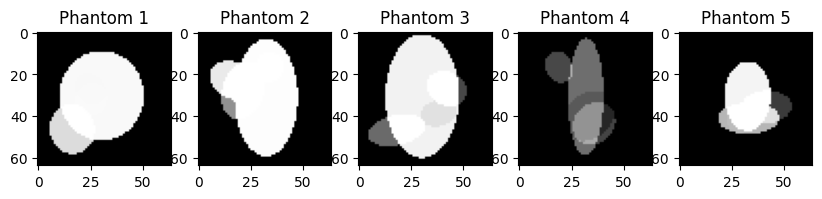

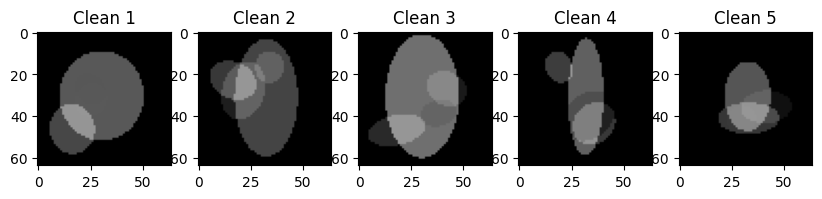

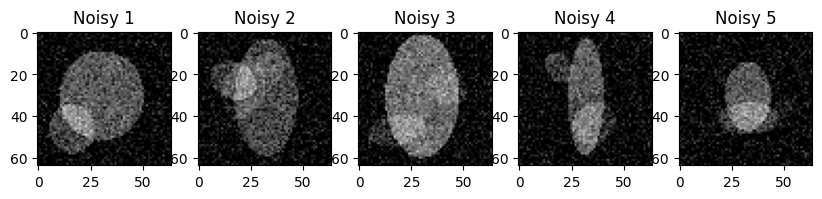

In [30]:
# Display some phantoms

fig, axs = plt.subplots(1, 5, figsize=(10, 3))
for idx, ax in enumerate(axs):
    ax.imshow(np_phan[idx], cmap=plt.cm.Greys_r, vmin=0, vmax=1)
    ax.set_title(f"Phantom {idx+1}")
fig, axs = plt.subplots(1, 5, figsize=(10, 3))
for idx, ax in enumerate(axs):
    ax.imshow(np_clean[idx], cmap=plt.cm.Greys_r, vmin=0, vmax=1)
    ax.set_title(f"Clean {idx+1}")
fig, axs = plt.subplots(1, 5, figsize=(10, 3))
for idx, ax in enumerate(axs):
    ax.imshow(np_noisy[idx], cmap=plt.cm.Greys_r, vmin=0, vmax=1)
    ax.set_title(f"Noisy {idx+1}")
plt.show()

## Baseline Model (Lecture Model 2)

In [31]:
import keras
from keras import layers

model_baseline = keras.Sequential([
    keras.Input(shape=(64, 64, 1)),
    # Encoder
    layers.Conv2D(15, 3, strides=2, activation="relu", padding="same"),   # 64->32, ch=15
    layers.Conv2D(15, 3,            activation="relu", padding="same"),   # 32->32, ch=15
    layers.Conv2D(20, 3, strides=2, activation="relu", padding="same"),   # 32->16, ch=20
    layers.Conv2D(20, 3,            activation="relu", padding="same"),   # 16->16, ch=20
    layers.Conv2D(25, 3, strides=2, activation="relu", padding="same"),   # 16->8,  ch=25
    layers.Conv2D(25, 3,            activation="relu", padding="same"),   # 8->8,   ch=25
    # Decoder
    layers.Conv2DTranspose(25, 3,            activation="relu", padding="same"),          # 8->8,   ch=25
    layers.Conv2DTranspose(25, 3, strides=2, activation="relu", padding="same"),          # 8->16,  ch=25
    layers.Conv2DTranspose(20, 3,            activation="relu", padding="same"),          # 16->16, ch=20
    layers.Conv2DTranspose(20, 3, strides=2, activation="relu", padding="same"),          # 16->32, ch=20
    layers.Conv2DTranspose(15, 3,            activation="relu", padding="same"),          # 32->32, ch=15
    layers.Conv2DTranspose(15, 3, strides=2, activation="relu", padding="same"),          # 32->64, ch=15
    # Output
    layers.Conv2D(1, 3, activation="relu", padding="same"),                # 64->64, ch=1
], name="baseline")

model_baseline.summary()
print(f"\nBaseline total parameters: {model_baseline.count_params():,}")


Model: "baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 15)     │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 15)     │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 20)     │         2,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 20)     │         3,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 25)       │         4,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 25)       │         5,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 25)       │         5,650 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 25)     │         5,650 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 20)     │         4,520 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 20)     │         3,620 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 15)     │         2,715 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 15)     │         2,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 1)      │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,036 (168.11 KB)

 Trainable params: 43,036 (168.11 KB)

 Non-trainable params: 0 (0.00 B)


Baseline total parameters: 43,036


In [32]:
model_baseline.compile(optimizer='adam', loss='mse')

history_baseline = model_baseline.fit(
    np_noisy, np_clean,
    epochs=100,
    shuffle=True,
    validation_data=(np_noisyV, np_cleanV)
)

baseline_val_mse = history_baseline.history['val_loss'][-1]
print(f"\nBaseline final train MSE: {history_baseline.history['loss'][-1]:.6f}")
print(f"Baseline final val   MSE: {baseline_val_mse:.6f}")


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0187 - val_loss: 0.0114
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0052 - val_loss: 0.0045
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0031 - val_loss: 0.0027
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0023 - val_loss: 0.0021
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0019 - val_loss: 0.0019
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0016 - val_loss: 0.0015
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014 - val_loss: 0.0014
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

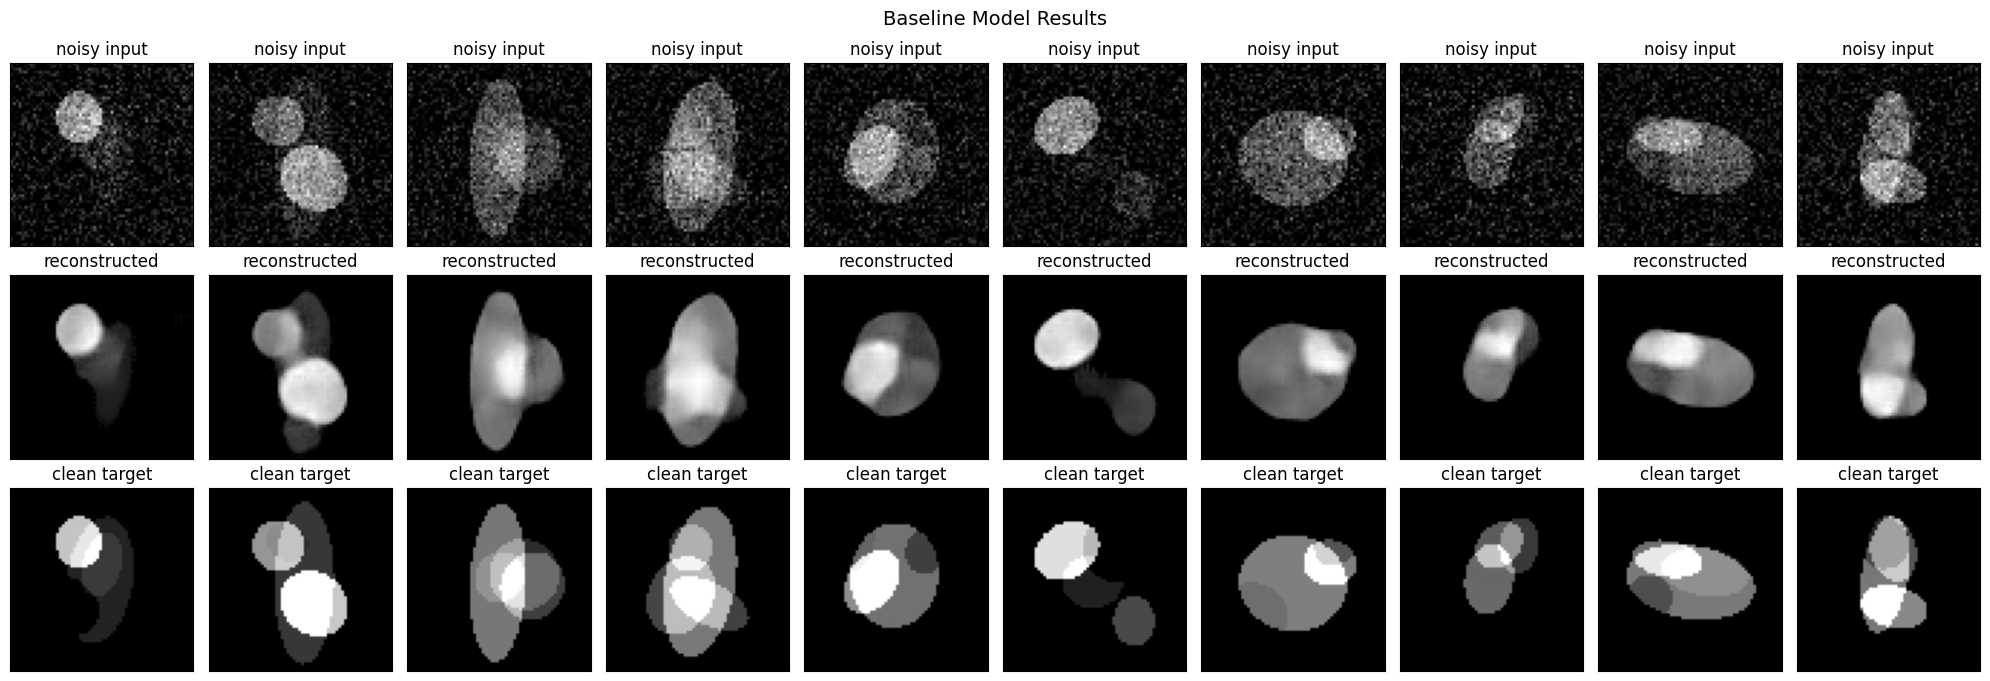

In [33]:
decoded_imgs = model_baseline(np_noisyV).numpy()

n = 10
plt.figure(figsize=(20, 7))
plt.suptitle("Baseline Model Results", fontsize=14)
plt.gray()
for i in range(n):
    bx = plt.subplot(3, n, i + 1)
    plt.title("noisy input")
    plt.imshow(tf.squeeze(np_noisyV[i]))
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)

    cx = plt.subplot(3, n, i + n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    cx.get_xaxis().set_visible(False)
    cx.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.title("clean target")
    plt.imshow(tf.squeeze(np_cleanV[i]))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()


## Case 1: Improved Performance — Wider & Deeper Sequential

**Change:** Increased channel widths (32/64/128/256 vs 15/20/25) and added a dedicated bottleneck layer.  
**Layers:** 14 conv layers total.  
**Channels:** 1 → 32 → 32 → 64 → 64 → 128 → 128 → 256 → 128 → 128 → 64 → 64 → 32 → 32 → 1  
**Total params:** ~1,162,945 (≈27× more than baseline)  
**Why improved:** Greater width gives richer feature representations at each scale. Sigmoid output correctly bounds predictions to [0,1].

In [34]:
model_case1 = keras.Sequential([
    keras.Input(shape=(64, 64, 1)),
    # Encoder
    layers.Conv2D(32,  3, strides=2, activation="relu", padding="same"),   # 64->32, ch=32
    layers.Conv2D(32,  3,            activation="relu", padding="same"),   # 32->32, ch=32
    layers.Conv2D(64,  3, strides=2, activation="relu", padding="same"),   # 32->16, ch=64
    layers.Conv2D(64,  3,            activation="relu", padding="same"),   # 16->16, ch=64
    layers.Conv2D(128, 3, strides=2, activation="relu", padding="same"),   # 16->8,  ch=128
    layers.Conv2D(128, 3,            activation="relu", padding="same"),   # 8->8,   ch=128
    # Bottleneck
    layers.Conv2D(256, 3,            activation="relu", padding="same"),   # 8->8,   ch=256
    # Decoder
    layers.Conv2DTranspose(128, 3,            activation="relu", padding="same"),  # 8->8,   ch=128
    layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same"),  # 8->16,  ch=128
    layers.Conv2DTranspose(64,  3,            activation="relu", padding="same"),  # 16->16, ch=64
    layers.Conv2DTranspose(64,  3, strides=2, activation="relu", padding="same"),  # 16->32, ch=64
    layers.Conv2DTranspose(32,  3,            activation="relu", padding="same"),  # 32->32, ch=32
    layers.Conv2DTranspose(32,  3, strides=2, activation="relu", padding="same"),  # 32->64, ch=32
    # Output
    layers.Conv2D(1, 3, activation="sigmoid", padding="same"),             # 64->64, ch=1
], name="case1_wider_deeper")

model_case1.summary()
print(f"\nCase 1 total parameters: {model_case1.count_params():,}")


Model: "case1_wider_deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 8, 8, 128)      │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 16, 16, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_10             │ (None, 32, 32, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_11             │ (None, 64, 64, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,162,945 (4.44 MB)

 Trainable params: 1,162,945 (4.44 MB)

 Non-trainable params: 0 (0.00 B)


Case 1 total parameters: 1,162,945


In [35]:
model_case1.compile(optimizer='adam', loss='mse')

history_case1 = model_case1.fit(
    np_noisy, np_clean,
    epochs=100,
    shuffle=True,
    validation_data=(np_noisyV, np_cleanV)
)

case1_val_mse = history_case1.history['val_loss'][-1]
print(f"\nCase 1 final train MSE: {history_case1.history['loss'][-1]:.6f}")
print(f"Case 1 final val   MSE: {case1_val_mse:.6f}")


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0955 - val_loss: 0.0234
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.0232 - val_loss: 0.0234
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step

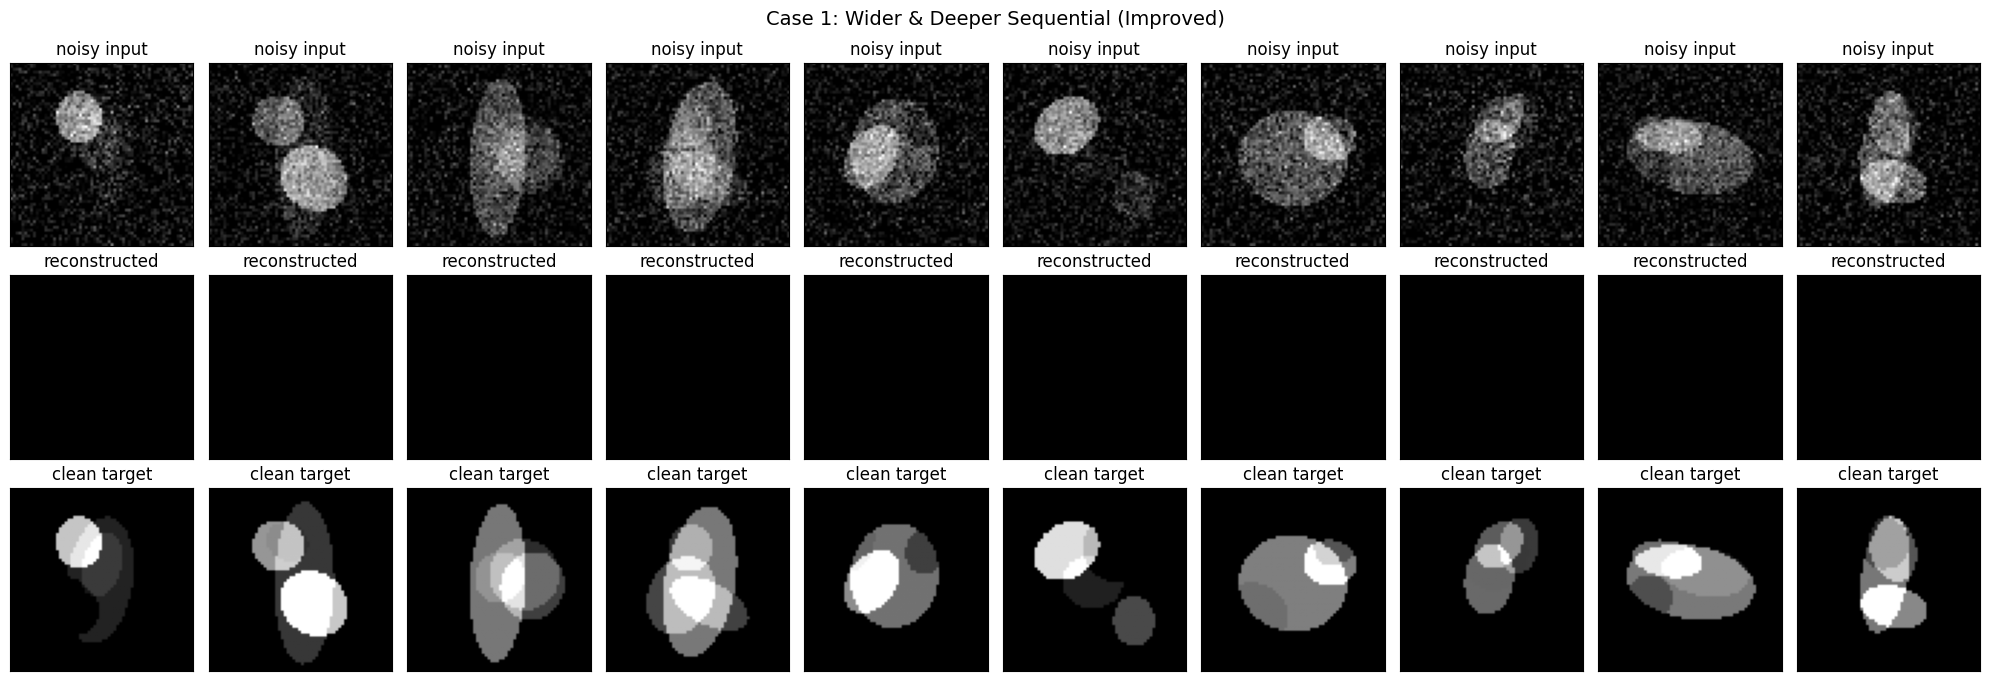

In [36]:
decoded_imgs_c1 = model_case1(np_noisyV).numpy()

n = 10
plt.figure(figsize=(20, 7))
plt.suptitle("Case 1: Wider & Deeper Sequential (Improved)", fontsize=14)
plt.gray()
for i in range(n):
    bx = plt.subplot(3, n, i + 1)
    plt.title("noisy input")
    plt.imshow(tf.squeeze(np_noisyV[i]))
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)

    cx = plt.subplot(3, n, i + n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs_c1[i]))
    cx.get_xaxis().set_visible(False)
    cx.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.title("clean target")
    plt.imshow(tf.squeeze(np_cleanV[i]))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()


## Case 2: Worsened Performance — Underpowered Shallow CNN

**Change:** Only 3 layers with 2 channels, no encoder-decoder structure.  
**Layers:** 3 conv layers total.  
**Channels:** 1 → 2 → 2 → 1  
**Total params:** 77 (≈560× fewer than baseline)  
**Why worsened:** 77 parameters is fundamentally insufficient to represent the denoising function. No multi-scale reasoning (no strided convolutions), almost no feature diversity (2 filters), severely underfit.

In [37]:
model_case2 = keras.Sequential([
    keras.Input(shape=(64, 64, 1)),
    layers.Conv2D(2, 3, activation="relu", padding="same"),  # ch=2 (3*3*1*2+2 = 20 params)
    layers.Conv2D(2, 3, activation="relu", padding="same"),  # ch=2 (3*3*2*2+2 = 38 params)
    layers.Conv2D(1, 3, activation="relu", padding="same"),  # ch=1 (3*3*2*1+1 = 19 params)
], name="case2_underpowered")

model_case2.summary()
print(f"\nCase 2 total parameters: {model_case2.count_params():,}")


Model: "case2_underpowered"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 2)      │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 2)      │            38 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 1)      │            19 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77 (308.00 B)

 Trainable params: 77 (308.00 B)

 Non-trainable params: 0 (0.00 B)


Case 2 total parameters: 77


In [38]:
model_case2.compile(optimizer='adam', loss='mse')

history_case2 = model_case2.fit(
    np_noisy, np_clean,
    epochs=100,
    shuffle=True,
    validation_data=(np_noisyV, np_cleanV)
)

case2_val_mse = history_case2.history['val_loss'][-1]
print(f"\nCase 2 final train MSE: {history_case2.history['loss'][-1]:.6f}")
print(f"Case 2 final val   MSE: {case2_val_mse:.6f}")


Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0220 - val_loss: 0.0201
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0188 - val_loss: 0.0182
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0180 - val_loss: 0.0180
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0174 - val_loss: 0.0157
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0136 - val_loss: 0.0114
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0099 - val_loss: 0.0085
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0076 - val_loss: 0.0067
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0051 - val_loss: 0.0046
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - val_loss: 0.0040
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0

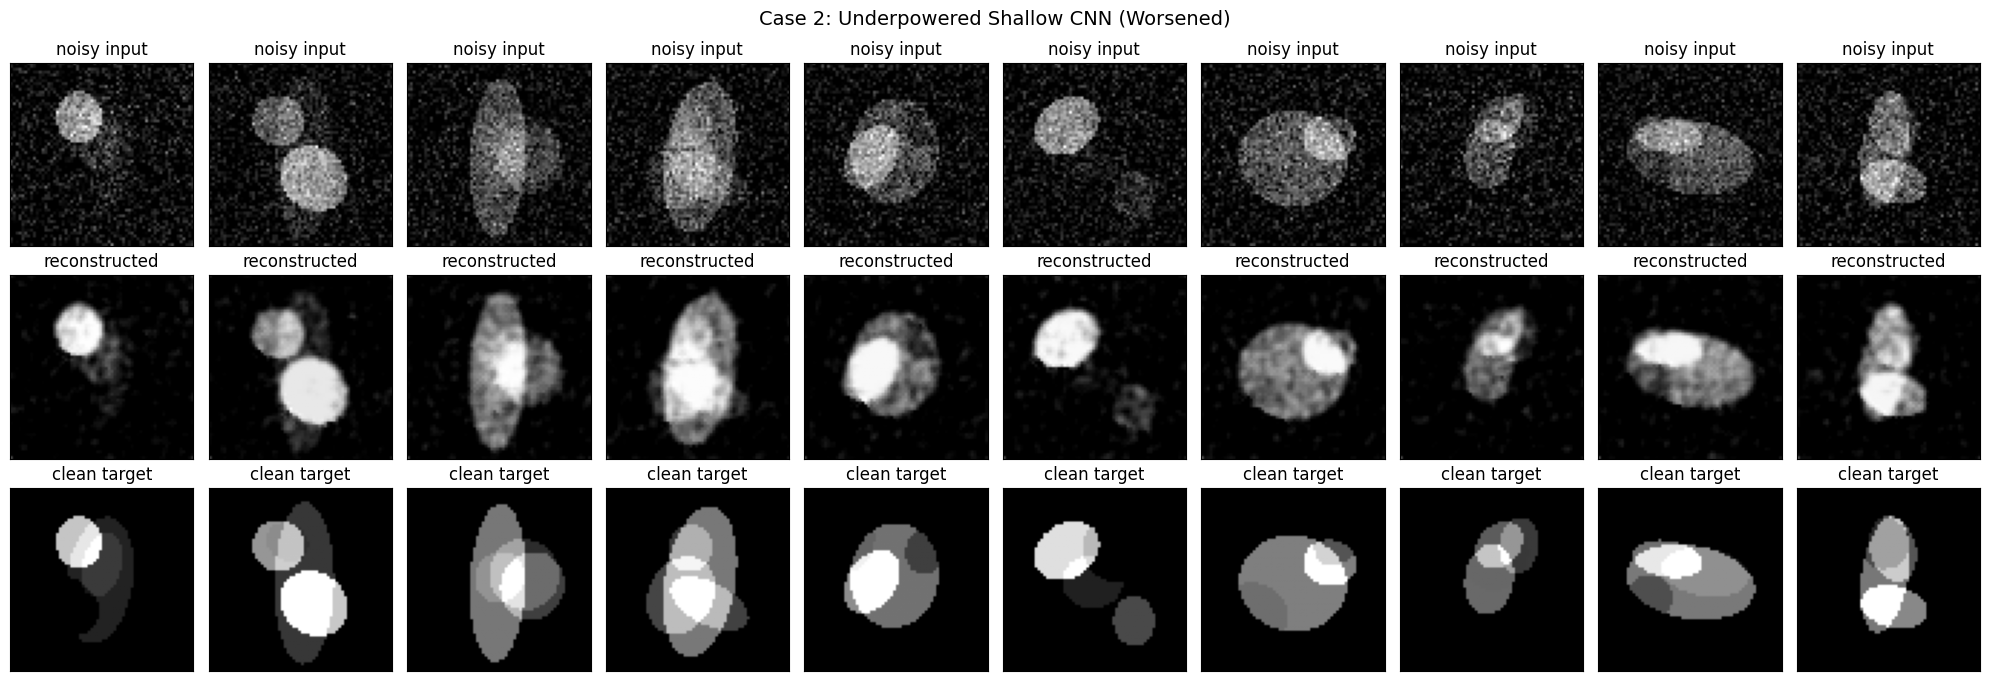

In [39]:
decoded_imgs_c2 = model_case2(np_noisyV).numpy()

n = 10
plt.figure(figsize=(20, 7))
plt.suptitle("Case 2: Underpowered Shallow CNN (Worsened)", fontsize=14)
plt.gray()
for i in range(n):
    bx = plt.subplot(3, n, i + 1)
    plt.title("noisy input")
    plt.imshow(tf.squeeze(np_noisyV[i]))
    bx.get_xaxis().set_visible(False)
    bx.get_yaxis().set_visible(False)

    cx = plt.subplot(3, n, i + n + 1)
    plt.title("reconstructed")
    plt.imshow(tf.squeeze(decoded_imgs_c2[i]))
    cx.get_xaxis().set_visible(False)
    cx.get_yaxis().set_visible(False)

    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.title("clean target")
    plt.imshow(tf.squeeze(np_cleanV[i]))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.tight_layout()
plt.show()


## Final Results Comparison

In [40]:
print("=" * 60)
print(f"{'Model':<12} {'Params':>12} {'Val MSE':>12}")
print("=" * 60)
print(f"{'Baseline':<12} {model_baseline.count_params():>12,} {history_baseline.history['val_loss'][-1]:>12.6f}")
print(f"{'Case 1':<12} {model_case1.count_params():>12,} {history_case1.history['val_loss'][-1]:>12.6f}")
print(f"{'Case 2':<12} {model_case2.count_params():>12,} {history_case2.history['val_loss'][-1]:>12.6f}")
print("=" * 60)
print()
print("Case 1 val MSE improvement over baseline:",
      f"{(history_baseline.history['val_loss'][-1] - history_case1.history['val_loss'][-1]):.6f}")
print("Case 2 val MSE degradation from baseline:",
      f"{(history_case2.history['val_loss'][-1] - history_baseline.history['val_loss'][-1]):.6f}")


Model              Params      Val MSE
Baseline           43,036     0.000742
Case 1          1,162,945     0.023359
Case 2                 77     0.000968

Case 1 val MSE improvement over baseline: -0.022617
Case 2 val MSE degradation from baseline: 0.000225
